# Linear Regression

$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

# 

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

from utils import *

## Cost Fuction

$$
J(w,b) = \frac{1}{2m} \sum \limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^{2} \tag{1}
$$ 


In [2]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        loss = (f_wb - y[i]) ** 2
        cost_sum += loss
    
    cost = cost_sum / (2 * m)
    return cost

# initial_w = 2
# initial_b = 1

# cost = compute_cost(x_train, y_train, initial_w, initial_b)
# print(type(cost))
# print(f'Cost at initial w (zeros): {cost:.3f}')

## Gradient descent

$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

In [3]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    j_history = []
    p_history = []
    
    w = w_in
    b = b_in

    print_step = max(0, math.ceil(num_iters / 10))
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = cost_function(x, y, w, b)
        j_history.append(cost)
        p_history.append([w, b])
        if i % print_step == 0:
            print(f'{i:10} - Cost: {cost:0.2e}, w: {w:0.3e}, b: {b:0.3e}, dj_dw: {dj_dw:0.3e}, dj_db: {dj_db:0.3e}')
    
    return w, b, j_history, p_history

# # Compute and display gradient with w initialized to zeroes
# initial_w = 0
# initial_b = 0

# tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
# print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

## Training

The shape of x_train is: (97, 1)
The shape of y_train is:  (97,)
Number of training examples (m): 97
Start training...
         0 - Cost: 6.74e+00, w: 6.533e-01, b: 5.839e-02, dj_dw: -6.533e+01, dj_db: -5.839e+00
       150 - Cost: 5.31e+00, w: 8.889e-01, b: -8.683e-01, dj_dw: -5.492e-02, dj_db: 5.467e-01
       300 - Cost: 4.96e+00, w: 9.610e-01, b: -1.586e+00, dj_dw: -4.190e-02, dj_db: 4.171e-01
       450 - Cost: 4.76e+00, w: 1.016e+00, b: -2.134e+00, dj_dw: -3.197e-02, dj_db: 3.182e-01
       600 - Cost: 4.64e+00, w: 1.058e+00, b: -2.552e+00, dj_dw: -2.439e-02, dj_db: 2.427e-01
       750 - Cost: 4.57e+00, w: 1.090e+00, b: -2.870e+00, dj_dw: -1.860e-02, dj_db: 1.852e-01
       900 - Cost: 4.53e+00, w: 1.114e+00, b: -3.113e+00, dj_dw: -1.419e-02, dj_db: 1.413e-01
      1050 - Cost: 4.51e+00, w: 1.133e+00, b: -3.299e+00, dj_dw: -1.083e-02, dj_db: 1.078e-01
      1200 - Cost: 4.50e+00, w: 1.147e+00, b: -3.440e+00, dj_dw: -8.261e-03, dj_db: 8.223e-02
      1350 - Cost: 4.49e+00, w: 1.1

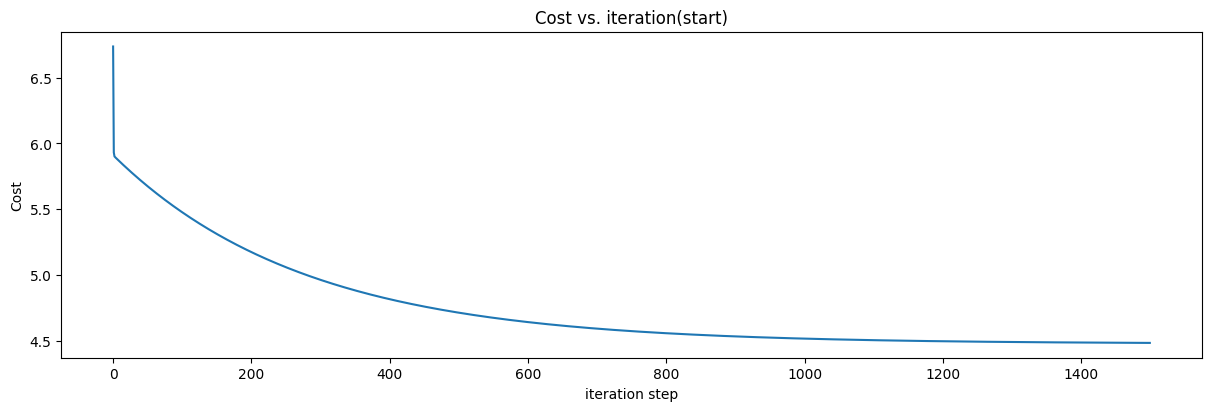

In [ ]:
ex_data_file = "data/ex1data1.txt"
x_train, y_train = load_data(ex_data_file)
print ('The shape of x_train is:', x_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(x_train))

w_init = 0
b_init = 0

alpha = 1.0e-2
iters_num = 1500

print('Start training...')
w, b, j_history, p_history = gradient_descent(x_train[:,0], y_train, w_init, b_init, alpha, iters_num, compute_cost, compute_gradient)

print(f'w = {w:8.4f}, b = {b:8.4f}')

# fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))

# ax1.set_title("Cost vs. iteration(start)");  
# ax1.set_ylabel('Cost') 
# ax1.set_xlabel('iteration step')
# ax1.plot(j_history[:100])

# ax2.set_title("Cost vs. iteration (end)")
# ax2.set_ylabel('Cost') 
# ax2.set_xlabel('iteration step') 
# ax2.plot(1000 + np.arange(len(j_history[1000:])), j_history[1000:])

fig, ax1 = plt.subplots(1, 1, constrained_layout=True, figsize=(12,4))

ax1.set_title("Cost vs. iteration(start)");  
ax1.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')
ax1.plot(j_history)

plt.show()

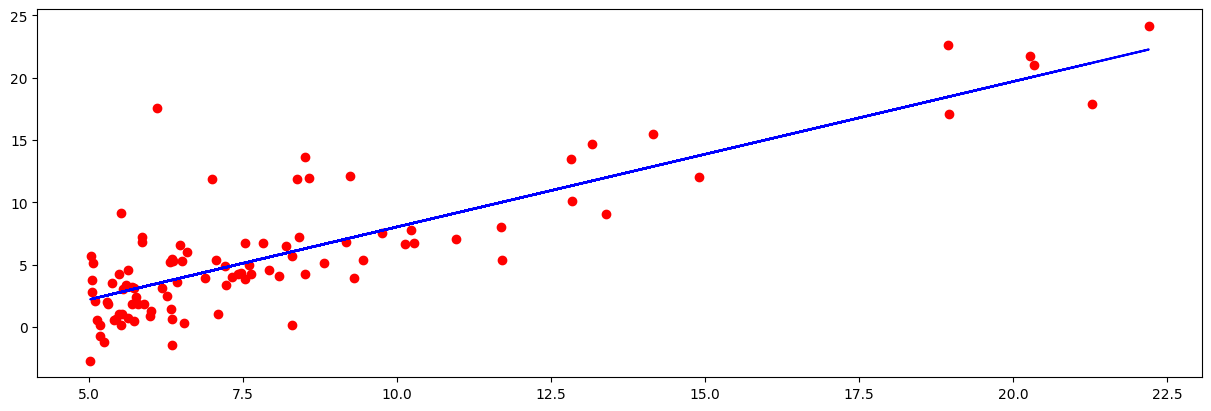

In [17]:
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(12,4))
ax.scatter(x_train, y_train, c="r")
y_pred = w * x_train + b
ax.plot(x_train, y_pred, c="b")
plt.show()